In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
print("Libraries loaded!")

Libraries loaded!


In [5]:
df = pd.read_csv('../data/cell2celltrain.csv')
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")


Rows: 51047, Columns: 58


In [6]:
df.head()

,CustomerID,Churn,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,...,ReferralsMadeBySubscriber,IncomeGroup,OwnsMotorcycle,AdjustmentsToCreditRating,HandsetPrice,MadeCallToRetentionTeam,CreditRating,PrizmCode,Occupation,MaritalStatus
0,3000002,Yes,24.00,219.0,22.0,0.25,0.0,0.0,-157.0,-19.0,...,0,4,No,0,30,Yes,1-Highest,Suburban,Professional,No
1,3000010,Yes,16.99,10.0,17.0,0.00,0.0,0.0,-4.0,0.0,...,0,5,No,0,30,No,4-Medium,Suburban,Professional,Yes
2,3000014,No,38.00,8.0,38.0,0.00,0.0,0.0,-2.0,0.0,...,0,6,No,0,Unknown,No,3-Good,Town,Crafts,Yes
3,3000022,No,82.28,1312.0,75.0,1.24,0.0,0.0,157.0,8.1,...,0,6,No,0,10,No,4-Medium,Other,Other,No
4,3000026,Yes,17.14,0.0,17.0,0.00,0.0,0.0,0.0,-0.2,...,0,9,No,1,10,No,1-Highest,Other,Professional,Yes


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51047 entries, 0 to 51046
Data columns (total 58 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CustomerID                 51047 non-null  int64  
 1   Churn                      51047 non-null  object 
 2   MonthlyRevenue             50891 non-null  float64
 3   MonthlyMinutes             50891 non-null  float64
 4   TotalRecurringCharge       50891 non-null  float64
 5   DirectorAssistedCalls      50891 non-null  float64
 6   OverageMinutes             50891 non-null  float64
 7   RoamingCalls               50891 non-null  float64
 8   PercChangeMinutes          50680 non-null  float64
 9   PercChangeRevenues         50680 non-null  float64
 10  DroppedCalls               51047 non-null  float64
 11  BlockedCalls               51047 non-null  float64
 12  UnansweredCalls            51047 non-null  float64
 13  CustomerCareCalls          51047 non-null  flo

In [8]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)

# Only show columns that actually have missing values
print(missing_df[missing_df['Missing Count'] > 0])

                       Missing Count  Missing %
AgeHH2                           909       1.78
AgeHH1                           909       1.78
PercChangeMinutes                367       0.72
PercChangeRevenues               367       0.72
MonthlyRevenue                   156       0.31
MonthlyMinutes                   156       0.31
TotalRecurringCharge             156       0.31
DirectorAssistedCalls            156       0.31
OverageMinutes                   156       0.31
RoamingCalls                     156       0.31
ServiceArea                       24       0.05
CurrentEquipmentDays               1       0.00
Handsets                           1       0.00
HandsetModels                      1       0.00


In [9]:
print(df['Churn'].value_counts())
print()
print(df['Churn'].value_counts(normalize=True) * 100)

Churn
No     36336
Yes    14711
Name: count, dtype: int64

Churn
No     71.18146
Yes    28.81854
Name: proportion, dtype: float64


In [10]:
df.dropna(inplace=True)

print(f"Rows after cleaning: {df.shape[0]}")
print(f"Rows removed: {51047 - df.shape[0]}")
print(f"Missing values remaining: {df.isnull().sum().sum()}")

Rows after cleaning: 49752
Rows removed: 1295
Missing values remaining: 0


In [11]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print("Churn column converted!")
print(df['Churn'].value_counts())

Churn column converted!
Churn
0    35507
1    14245
Name: count, dtype: int64


In [12]:
df.to_csv('../data/cell2cell_clean.csv', index=False)
print("Clean file saved!")

Clean file saved!


CHART 1 - Churn Distribution

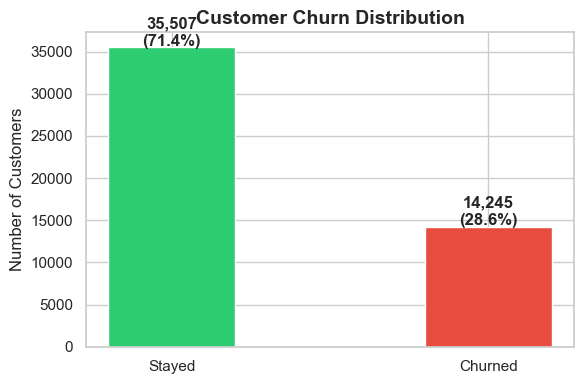

In [13]:
fig, ax = plt.subplots(figsize=(6, 4))

labels = ['Stayed', 'Churned']
sizes = df['Churn'].value_counts()
colors = ['#2ecc71', '#e74c3c']

ax.bar(labels, sizes, color=colors, width=0.4)
ax.set_title('Customer Churn Distribution', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Customers')

for i, v in enumerate(sizes):
    ax.text(i, v + 200, f'{v:,}\n({v/len(df)*100:.1f}%)', 
            ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../images/01_churn_distribution.png', dpi=150)
plt.show()


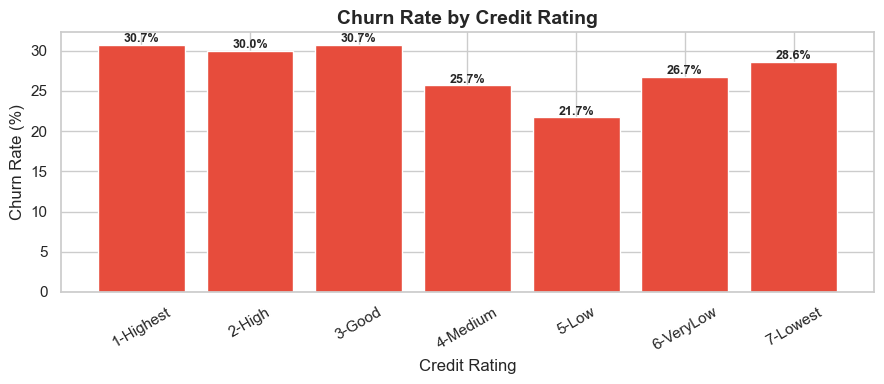

In [19]:
# Define logical order from best to worst credit
credit_order = ['1-Highest', '2-High', '3-Good', '4-Medium', '5-Low', '6-VeryLow', '7-Lowest']

churn_by_credit = df.groupby('CreditRating')['Churn'].mean() * 100
churn_by_credit = churn_by_credit.reindex(credit_order)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(credit_order, churn_by_credit, color='#e74c3c')

ax.set_title('Churn Rate by Credit Rating', fontsize=14, fontweight='bold')
ax.set_ylabel('Churn Rate (%)')
ax.set_xlabel('Credit Rating')
plt.xticks(rotation=30)

for bar, val in zip(bars, churn_by_credit):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('../images/02_churn_by_credit.png', dpi=150)
plt.show()

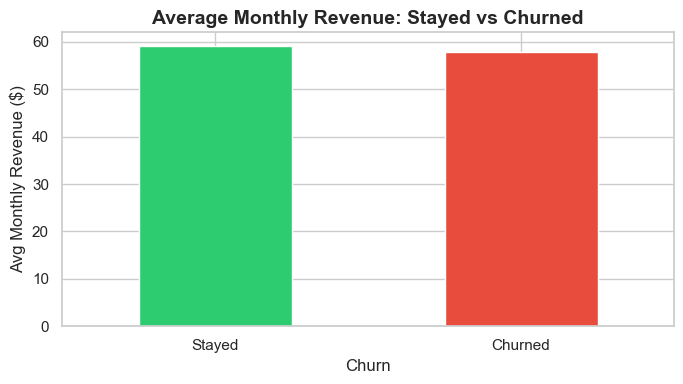

In [20]:
fig, ax = plt.subplots(figsize=(7, 4))

df.groupby('Churn')['MonthlyRevenue'].mean().plot(
    kind='bar', color=['#2ecc71', '#e74c3c'], ax=ax
)

ax.set_title('Average Monthly Revenue: Stayed vs Churned', 
             fontsize=14, fontweight='bold')
ax.set_ylabel('Avg Monthly Revenue ($)')
ax.set_xticklabels(['Stayed', 'Churned'], rotation=0)

plt.tight_layout()
plt.savefig('../images/03_revenue_by_churn.png', dpi=150)
plt.show()

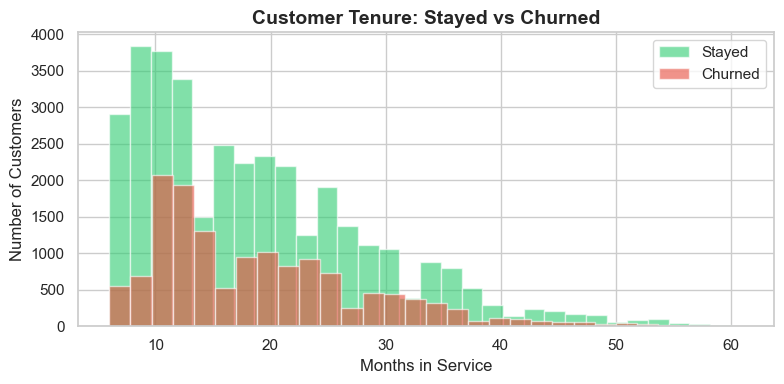

In [16]:
fig, ax = plt.subplots(figsize=(8, 4))

df[df['Churn'] == 0]['MonthsInService'].plot(
    kind='hist', bins=30, alpha=0.6, color='#2ecc71', 
    label='Stayed', ax=ax
)
df[df['Churn'] == 1]['MonthsInService'].plot(
    kind='hist', bins=30, alpha=0.6, color='#e74c3c', 
    label='Churned', ax=ax
)

ax.set_title('Customer Tenure: Stayed vs Churned', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Months in Service')
ax.set_ylabel('Number of Customers')
ax.legend()

plt.tight_layout()
plt.savefig('../images/04_tenure_by_churn.png', dpi=150)
plt.show()

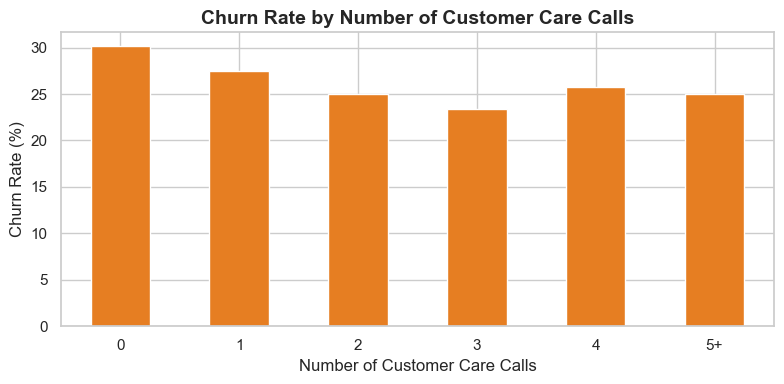

In [18]:
# Cap calls at 5+ to keep the chart clean and readable
df['CareCallsGroup'] = df['CustomerCareCalls'].apply(
    lambda x: '5+' if x >= 5 else str(int(x))
)

# Define the order so bars go 0, 1, 2, 3, 4, 5+
order = ['0', '1', '2', '3', '4', '5+']

churn_by_calls = (
    df.groupby('CareCallsGroup')['Churn']
    .mean()
    .mul(100)
    .reindex(order)
)

fig, ax = plt.subplots(figsize=(8, 4))
churn_by_calls.plot(kind='bar', color='#e67e22', ax=ax)

ax.set_title('Churn Rate by Number of Customer Care Calls',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Churn Rate (%)')
ax.set_xlabel('Number of Customer Care Calls')
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig('../images/05_customercare_churn.png', dpi=150)
plt.show()